<a href="https://colab.research.google.com/github/Zineb9876/Projet-Deep-Learning/blob/main/Copy_of_Untitled2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Étape 1 : Chargement et affichage de l’image**

Dans cette étape, nous avons importé les bibliothèques nécessaires telles que NumPy, OpenCV et Matplotlib, ainsi que l’image "ascent" fournie par SciPy.

L’image est ensuite affichée afin de visualiser son contenu. Il s’agit d’une image en niveaux de gris représentant un escalier, contenant plusieurs caractéristiques importantes comme des lignes verticales et des contours.

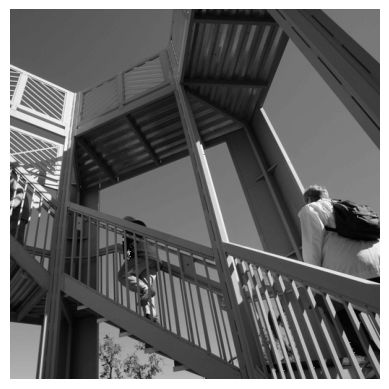

In [24]:
import cv2
import numpy as np
from scipy import datasets
i = datasets.ascent()
import matplotlib.pyplot as plt
plt.grid(False)
plt.gray()
plt.axis('off')
plt.imshow(i)
plt.show()
i_transformed = np.copy(i)
size_x = i_transformed.shape[0]
size_y = i_transformed.shape[1]

## **Étape 2 : Application de la convolution**

Dans cette étape, nous avons appliqué une convolution à l’image à l’aide d’un filtre 3×3. Ce filtre permet de détecter certaines caractéristiques spécifiques comme les contours ou les lignes.
Le principe consiste à parcourir chaque pixel de l’image et à effectuer une opération de multiplication entre les pixels voisins et les valeurs du filtre. Le résultat est ensuite stocké dans une nouvelle image transformée.

In [25]:
#filtre = [ [0, 1, 0], [1, -4, 1], [0, 1, 0]]

# Encore quelques filtres à essayer pour le plaisir!
filtre = [ [-1, -2, -1], [0, 0, 0], [1, 2, 1]]
#filtre = [ [-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]

poids = 10
i_float = np.float32(i)
for x in range(1, size_x-1):
    for y in range(1, size_y-1):
        out = 0.0

        out += i_float[x-1, y-1] * filtre[0][0]
        out += i_float[x,   y-1] * filtre[0][1]
        out += i_float[x+1, y-1] * filtre[0][2]

        out += i_float[x-1, y] * filtre[1][0]
        out += i_float[x,   y] * filtre[1][1]
        out += i_float[x+1, y] * filtre[1][2]

        out += i_float[x-1, y+1] * filtre[2][0]
        out += i_float[x,   y+1] * filtre[2][1]
        out += i_float[x+1, y+1] * filtre[2][2]

        out = out * poids


        if out < 0:
            out = 0
        if out > 255:
            out = 255

        i_transformed[x, y] = out

# **Étape 3 : Visualisation du résultat**

Après l’application du filtre, l’image transformée est affichée pour observer les effets de la convolution.

Selon le filtre utilisé, certaines caractéristiques deviennent plus visibles, notamment les lignes verticales dans le cas du filtre [-1,0,1,...].

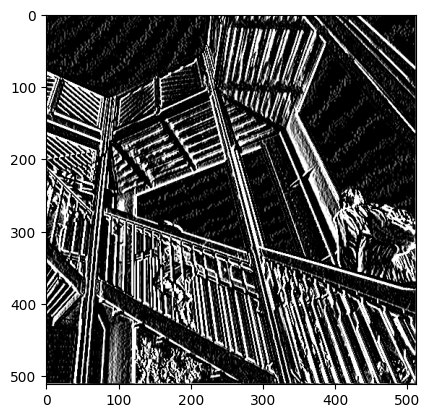

In [26]:
# Tracez l'image. Notez la taille des axes - ils sont 512 par 512
plt.gray()
plt.grid(False)
plt.imshow(i_transformed)
plt.show()

# **Étape 4 : Pooling (Max Pooling)**

Le pooling est une technique utilisée pour réduire la taille d’une image tout en conservant ses caractéristiques importantes.

Dans ce TP, nous avons utilisé le max pooling (2×2), qui consiste à diviser l’image en blocs de 2×2 pixels et à conserver uniquement la valeur maximale de chaque bloc.

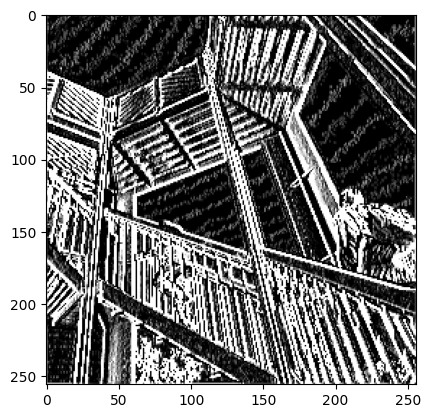

In [27]:
new_x = int(size_x / 2)
new_y = int(size_y / 2)

newImage = np.zeros((new_x, new_y))

for x in range(0, size_x, 2):
    for y in range(0, size_y, 2):
        pixels = []

        pixels.append(i_transformed[x, y])
        pixels.append(i_transformed[x+1, y])
        pixels.append(i_transformed[x, y+1])
        pixels.append(i_transformed[x+1, y+1])

        pixels.sort(reverse=True)

        newImage[int(x/2), int(y/2)] = pixels[0]

# tracer l’image
plt.gray()
plt.grid(False)
plt.imshow(newImage)
# plt.axis('off')
plt.show()